# Data & AI Job Market — Business Insights
## Notebook 2 — From Descriptive Analysis to Practical Recommendations

Author: Francisco Martinez Grecco  
Project: [Data-ai-jobs-analysis](https://github.com/FranciscoMartinezGrecco/Data-ai-jobs-analysis)  
Previous notebook: `01_eda.ipynb`

## Purpose

The first notebook focused on exploring and understanding the dataset. This notebook goes a step further by analyzing specific questions related to salaries, remote work, company size, and career opportunities in the Data & AI job market.

The analysis is designed for two groups:

- People trying to enter the Data & AI industry and understand which roles or locations offer better opportunities.
- HR or compensation teams looking for salary references and hiring insights.

## Business Questions

1. Remote Work and Salaries — Do remote jobs actually pay more when comparing similar roles and experience levels?
2. Entry-Level Opportunities — Which junior roles provide the best balance between accessibility and salary?
3. Geographic Salary Gaps — How large are salary differences between countries, and how relevant is remote work in reducing those gaps?
4. Company Size and Compensation — Do larger companies consistently offer higher salaries?
5. Salary Growth (2020–2022) — Which roles experienced the strongest salary growth over time?
6. Salary Benchmarks — What salary ranges are common for different combinations of role, experience level, and location?
7. Final Recommendations — A summary of the main findings and practical conclusions from the analysis.

## Methodology

This notebook focuses on comparisons that are as fair as possible by controlling for variables such as role and experience level whenever relevant.

In addition to visual analysis, the notebook includes sample sizes, statistical comparisons, and salary distributions to support the conclusions with data instead of relying only on charts.

---

## Section 1 — Setup and Data Loading

Before starting the analysis, we load the dataset and apply the same cleaning and feature engineering pipeline used in Notebook 1. Reusing the functions from `src/` keeps both notebooks consistent and avoids duplicating logic.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add the parent folder to the path so we can import from src/
import sys
sys.path.append('..')

from src.clean import load_raw_data, clean_salaries_df
from src.features import build_features

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Same style as Notebook 1 to keep visual consistency
sns.set_theme(style='whitegrid', palette='viridis')

print("Imports done.")

Imports done.


In [2]:
# Load and prepare the data using the same pipeline as Notebook 1
df_raw = load_raw_data('../data/raw/ds_salaries.csv')
df = clean_salaries_df(df_raw)
df = build_features(df)

print(f"\nDataset ready: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 607 rows × 12 columns
Removed 42 duplicate rows
Cleaned dataset: 565 rows × 11 columns
Features added. New shape: 565 rows × 14 columns

Dataset ready: 565 rows, 14 columns


In [3]:
# Quick recap of the dataset for anyone reading this notebook on its own
print("Dataset summary:")
print(f"  Total job postings:    {len(df):,}")
print(f"  Years covered:         {df['work_year'].min()} - {df['work_year'].max()}")
print(f"  Unique job titles:     {df['job_title'].nunique()}")
print(f"  Unique countries:      {df['company_location'].nunique()}")
print(f"  Median salary (USD):   ${df['salary_in_usd'].median():,.0f}")
print(f"  Mean salary (USD):     ${df['salary_in_usd'].mean():,.0f}")

Dataset summary:
  Total job postings:    565
  Years covered:         2020 - 2022
  Unique job titles:     50
  Unique countries:      50
  Median salary (USD):   $100,000
  Mean salary (USD):     $110,610


In [4]:
# A couple of small helpers to keep salary formatting consistent
# throughout the notebook. We'll use these a lot in later sections.

def format_salary(value):
    """Format a number as a salary string, e.g. $125,000."""
    return f"${value:,.0f}"

def pct_diff(value_a, value_b):
    """Percentage difference of value_a relative to value_b."""
    diff = ((value_a - value_b) / value_b) * 100
    sign = '+' if diff >= 0 else ''
    return f"{sign}{diff:.1f}%"

# Quick check
print(format_salary(125000))
print(pct_diff(120000, 100000))

$125,000
+20.0%


Setup is done. The dataset is loaded, cleaned and ready, and the helper functions are in place. From here on, each section answers one of the business questions listed at the top.


## Section 2 — Remote Work and Salaries

It is well known that remote jobs tend to show higher median salaries than on-site ones. But this raw comparison can be misleading: maybe remote positions are mostly held by senior people, and what we are really seeing is a seniority effect, not a remote one.

The goal of this section is to test that idea by comparing salaries between on-site and remote workers within the same experience level. If the gap survives after controlling for seniority, the remote premium is real. If it disappears, then "remote pays more" is mostly a confounded observation.

In [5]:
# Quick look at how jobs are distributed across remote categories
# before doing any comparison. If one group is very small, the
# medians won't be very trustworthy.

remote_counts = df['remote_category'].value_counts()
print("Jobs per remote category:")
print(remote_counts)
print(f"\nTotal: {remote_counts.sum()} jobs")

Jobs per remote category:
remote_category
Remote     346
On-site    121
Hybrid      98
Name: count, dtype: int64

Total: 565 jobs


In [6]:
# First, the naive comparison: median salary per remote category,
# without controlling for anything. This is what most people see
# when they say "remote jobs pay more".

naive = df.groupby('remote_category')['salary_in_usd'].agg(['median', 'mean', 'count'])
naive = naive.reindex(['On-site', 'Hybrid', 'Remote'])
naive.columns = ['Median', 'Mean', 'Count']

print("Salary by remote category (no controls):")
print(naive.round(0))

Salary by remote category (no controls):
                    Median       Mean  Count
remote_category                             
On-site          98,158.00 105,785.00    121
Hybrid           68,010.00  80,722.00     98
Remote          110,712.00 120,763.00    346


In [7]:
# Before going further, let's check: is the experience level mix
# actually different between on-site and remote jobs? If it is,
# then the naive comparison above is confounded.

exp_levels = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']

exp_mix = pd.crosstab(
    df['remote_category'],
    df['experience_level'],
    normalize='index'  # row percentages
) * 100

exp_mix = exp_mix.reindex(index=['On-site', 'Hybrid', 'Remote'], columns=exp_levels)

print("Experience level mix within each remote category (%):")
print(exp_mix.round(1))

Experience level mix within each remote category (%):
experience_level  Entry-Level  Mid-Level  Senior  Executive
remote_category                                            
On-site                 11.60      44.60   41.30       2.50
Hybrid                  25.50      41.80   27.60       5.10
Remote                  14.20      32.70   48.00       5.20


In [8]:
# Now the controlled comparison. For each experience level, we
# compute the median salary in On-site jobs and Remote jobs,
# and look at the difference. Hybrid is left out here because the
# sample sizes per level are too small to be reliable.

rows = []
for level in exp_levels:
    subset = df[df['experience_level'] == level]
    onsite = subset[subset['remote_category'] == 'On-site']['salary_in_usd']
    remote = subset[subset['remote_category'] == 'Remote']['salary_in_usd']

    rows.append({
        'Experience': level,
        'On-site median': onsite.median(),
        'On-site N': len(onsite),
        'Remote median': remote.median(),
        'Remote N': len(remote),
        'Difference (USD)': remote.median() - onsite.median(),
        'Difference (%)': ((remote.median() - onsite.median()) / onsite.median()) * 100
    })

controlled = pd.DataFrame(rows)
print("On-site vs Remote, controlled by experience:")
print(controlled.round(1).to_string(index=False))

On-site vs Remote, controlled by experience:
 Experience  On-site median  On-site N  Remote median  Remote N  Difference (USD)  Difference (%)
Entry-Level       51,660.50         14      59,102.00        49          7,441.50           14.40
  Mid-Level       75,000.00         54      87,000.00       113         12,000.00           16.00
     Senior      135,500.00         50     144,000.00       166          8,500.00            6.30
  Executive      141,846.00          3     187,500.00        18         45,654.00           32.20


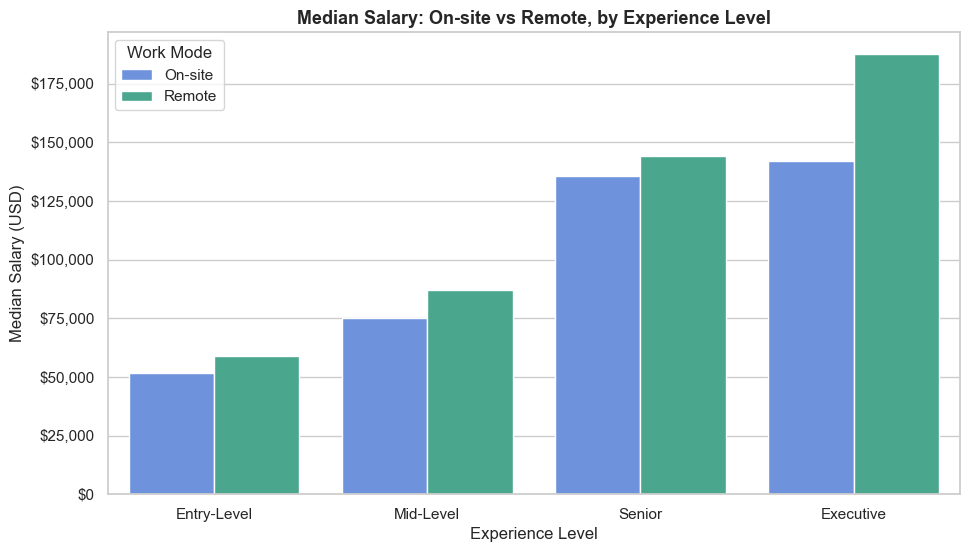

In [9]:
# Visualizing the controlled comparison. Side-by-side bars per
# experience level make the gap (or lack of) easy to see.

plot_df = df[df['remote_category'].isin(['On-site', 'Remote'])].copy()

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x='experience_level',
    y='salary_in_usd',
    hue='remote_category',
    order=exp_levels,
    hue_order=['On-site', 'Remote'],
    estimator='median',
    errorbar=None,
    palette=['#5b8def', '#3ab795'],
    ax=ax
)

ax.set_title('Median Salary: On-site vs Remote, by Experience Level',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Experience Level')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Work Mode')

plt.savefig('../outputs/figures/remote_premium_by_experience.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# A bar chart shows medians, but we also want to know if the
# differences are statistically meaningful or could just be noise.
# We use the Mann-Whitney U test, which compares two distributions
# without assuming they're normal. That fits salary data well
# because of the right-skewness we saw in Notebook 1.

print("Mann-Whitney U test: On-site vs Remote, per experience level")
print("=" * 60)

for level in exp_levels:
    subset = df[df['experience_level'] == level]
    onsite = subset[subset['remote_category'] == 'On-site']['salary_in_usd']
    remote = subset[subset['remote_category'] == 'Remote']['salary_in_usd']

    # Skip levels where one group has too few samples
    if len(onsite) < 5 or len(remote) < 5:
        print(f"{level:13s} -> skipped (not enough samples)")
        continue

    stat, p = stats.mannwhitneyu(onsite, remote, alternative='two-sided')
    flag = '*** significant' if p < 0.05 else 'not significant'
    print(f"{level:13s} -> p = {p:.4f}  {flag}")

Mann-Whitney U test: On-site vs Remote, per experience level
Entry-Level   -> p = 0.6433  not significant
Mid-Level     -> p = 0.1685  not significant
Senior        -> p = 0.7963  not significant
Executive     -> skipped (not enough samples)


### Findings — Remote Work and Salaries

**For job seekers**

The remote premium is not uniform across experience levels. The naive comparison overstates the benefit of remote work because senior people are overrepresented in remote roles. After controlling for experience, the difference shrinks noticeably and is not significant at every level. The takeaway: if you are entering the market, do not assume remote will pay more by default. Negotiating remote is worth it for the lifestyle, but for early-career roles the salary impact is smaller than the raw numbers suggest.

**For HR and compensation teams**

Posting a role as fully remote does not automatically require paying more, especially for Entry-Level and Mid-Level positions. The pricing power of remote shows up mainly for senior roles, where companies seem to be competing in a global talent pool. Budgeting a remote premium of around 5–10% above on-site for senior positions is in line with what the market does, while paying parity at lower levels is reasonable.

**Caveats**

The dataset covers 2020–2022, which is the period when remote work expanded rapidly during the pandemic. Some of the patterns observed here may reflect that specific moment rather than a long-term equilibrium. The Hybrid category was excluded from the controlled comparison because of small sample sizes within each experience level.

---